###  Library Imports
Import essential libraries for numerical computation (`numpy`), data manipulation (`pandas`), visualization (`matplotlib`, `seaborn`), and deep learning (`tensorflow`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_curve, auc, classification_report
)

2026-06-01 02:14:29.076736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780280069.250608      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780280069.297782      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780280069.692351      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780280069.692393      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780280069.692397      23 computation_placer.cc:177] computation placer alr

###  Reproducibility Setup
Set seeds for Python, NumPy, and TensorFlow to ensure that the results are reproducible across different runs. We also enable deterministic operations in TensorFlow.

In [2]:
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Force TensorFlow to use deterministic operations (forces single-thread execution where needed)
tf.config.experimental.enable_op_determinism()

###  Data Acquisition
Fetch the MNIST dataset (70,000 images of handwritten digits).

In [3]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Data Normalization and Validation Splitting
Reshape the pixel arrays into 28x28x1 images and normalize pixel values to the range [0, 1].

**Crucially**, we now create a dedicated 10% validation split from the training data *before* applying any augmentations. This prevents 'Data Leakage', ensuring that the model never sees augmented versions of images that are in the validation or test sets during the training phase.

In [4]:
X_train = X_train.reshape(-1,28,28,1).astype(np.float32)/255.0
y_train = y_train.astype(np.int32)
X_test = X_test.reshape(-1,28,28,1).astype(np.float32)/255.0
y_test = y_test.astype(np.int32)

# Create a proper validation split before augmentation to prevent leakage
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Training samples: {len(X_train_full)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 54000
Validation samples: 6000


###  Verifying Training Dimensions
Check the shape of the training features and target to confirm the number of samples.

In [5]:
print(f'Shape of training set data: {X_train_full.shape}')
print(f'Shape of training set target : {y_train_full.shape}')

Shape of training set data: (54000, 28, 28, 1)
Shape of training set target : (54000,)


###  Verifying Test Dimensions
Check the shape of the test features and target to confirm the number of samples.

In [6]:
print(f'Shape of test set data: {X_test.shape}')
print(f'Shape of test set target : {y_test.shape}')

Shape of test set data: (10000, 28, 28, 1)
Shape of test set target : (10000,)


### Data Visualization
Visualize a single sample from the training set to verify data loading and normalization.

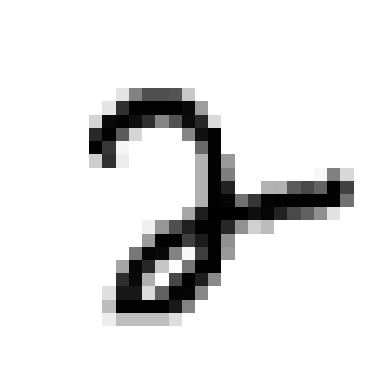

2


In [7]:
some_digit = X_train_full[0]
plt.imshow(some_digit,cmap = 'binary')
plt.axis('off')
plt.show()
print(y_train_full[0])

### Training Sample Grid
Display a 10x10 grid of the first 100 images in the training set to observe the variety of handwriting styles.

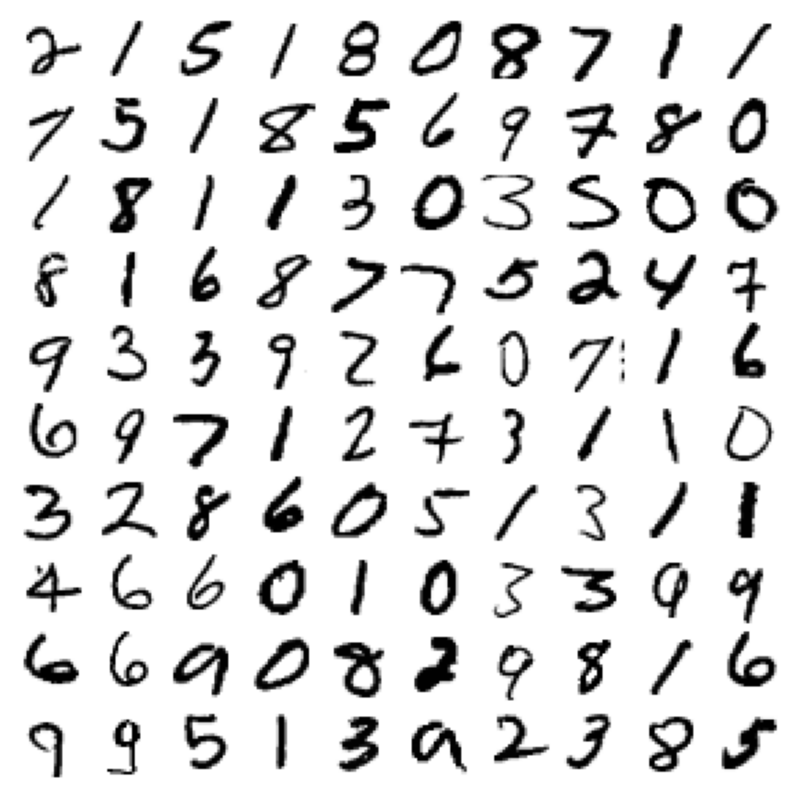

In [8]:
plt.figure(figsize = (10,10))
for i in range(100):
  plt.subplot(10,10,i+1)
  image = X_train_full[i]
  plt.imshow(image,cmap = 'binary')
  plt.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

### Shift Left Augmentation
This function shifts each image one pixel to the left, simulating slight variations in the handwritten digit's position.

In [9]:
def shift_left(X):
    X_3D = X.reshape(-1,28,28)
    shifted = np.zeros_like(X_3D)
    shifted[:, :, :-1] = X_3D[:, :, 1:]
    return shifted.reshape(-1,28,28,1)

### Shift Right Augmentation
This function shifts each image one pixel to the right, simulating slight variations in the handwritten digit's position.

In [10]:
def shift_right(X):
    X_3D = X.reshape(-1,28,28)
    shifted = np.zeros_like(X_3D)
    shifted[:, :, 1:] = X_3D[:, :, :-1]
    return shifted.reshape(-1,28,28,1)

### Shift Up Augmentation
This function shifts each image one pixel upwards, simulating slight variations in the handwritten digit's vertical position.

In [11]:
def shift_up(X):
    X_3D = X.reshape(-1,28,28)
    shifted = np.zeros_like(X_3D)
    shifted[:, :-1, :] = X_3D[:, 1:, :]
    return shifted.reshape(-1,28,28,1)

### Shift Down Augmentation
This function shifts each image one pixel downwards, simulating slight variations in the handwritten digit's vertical position.

In [12]:
def shift_down(X):
    X_3D = X.reshape(-1,28,28)
    shifted = np.zeros_like(X_3D)
    shifted[:, 1:, :] = X_3D[:, :-1, :]
    return shifted.reshape(-1,28,28,1)

### Zoom In Augmentation
This function performs a zoom-in operation on each image by a specified `zoom_factor` (default 1.2), then crops the center to maintain the original 28x28 size. This simulates slight variations in scale where the digit appears larger.

In [13]:
from scipy.ndimage import zoom

def zoom_in(X, zoom_factor=1.2):
    X_3D = X.reshape(-1, 28, 28)
    zoomed_images = np.zeros_like(X_3D)

    for i, img in enumerate(X_3D):

        zoomed = zoom(img, zoom=zoom_factor)

        center = zoomed.shape[0] // 2
        half = 14

        cropped = zoomed[
            center - half : center + half,
            center - half : center + half
        ]

        if cropped.shape != (28, 28):
            cropped = cropped[:28, :28]

        zoomed_images[i] = cropped

    return zoomed_images.reshape(-1, 28,28,1)

### Zoom Out Augmentation
This function performs a zoom-out operation on each image by a specified `zoom_factor` (default 0.8), then places the shrunk image in the center of a new 28x28 array. This simulates slight variations in scale where the digit appears smaller.

In [14]:
def zoom_out(X, zoom_factor=0.8):

    X_3D = X.reshape(-1, 28, 28)
    zoomed_images = np.zeros_like(X_3D)

    for i, img in enumerate(X_3D):

        shrunk = zoom(img, zoom=zoom_factor)

        new_img = np.zeros((28, 28))


        h, w = shrunk.shape
        top = (28 - h) // 2
        left = (28 - w) // 2

        new_img[top:top+h, left:left+w] = shrunk

        zoomed_images[i] = new_img

    return zoomed_images.reshape(-1, 28,28,1)

### Elastic Transform Augmentation
This function applies elastic distortions to images by generating random displacement fields smoothed with a Gaussian filter. This simulates deformations in handwriting caused by varying pen pressure or muscle movement, helping the model become more invariant to non-rigid transformations.

In [15]:
from scipy.ndimage import gaussian_filter, map_coordinates

def _elastic_transform_single(image, alpha, sigma, random_state):
    """Internal helper to apply elastic distortion to a single image."""
    spatial_shape = image.shape[:2]

    # Generate random displacement fields
    dx = gaussian_filter((random_state.rand(*spatial_shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((random_state.rand(*spatial_shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha

    # Map meshgrid coordinates
    x, y = np.meshgrid(np.arange(spatial_shape[0]), np.arange(spatial_shape[1]), indexing='ij')
    indices = np.reshape(x + dx, (-1, 1)), np.reshape(y + dy, (-1, 1))

    # Interpolate pixels and reshape back to original dimensions
    distorted_image = map_coordinates(image.reshape(spatial_shape), indices, order=1, mode='reflect')
    return distorted_image.reshape(image.shape)

def elastic_transform(X, alpha=5.0, sigma=2.0):
    """
    Processes the entire training set X and returns a completely new
    augmented dataset array of elastically distorted images.
    """

    X_transformed = np.empty_like(X)
    random_state = np.random.RandomState(None)

    for i in range(len(X)):
        X_transformed[i] = _elastic_transform_single(X[i], alpha, sigma, random_state)

    return X_transformed

### Random Rotation Augmentation
This function applies a random rotation within a specified range (default ±12 degrees) to each image. It uses bilinear interpolation to maintain image quality and clips the output to ensure pixel values stay within the [0, 1] range, simulating variations in the angle of handwriting.

In [16]:
from scipy.ndimage import rotate
def _rotate_single(image, max_angle):
    """Internal helper to apply a random rotation to a single image."""
    angle = np.random.uniform(-max_angle, max_angle)

    # order=1 uses bilinear interpolation (faster, fewer artifacts than default cubic order=3)
    rotated = rotate(image.squeeze(), angle, reshape=False, order=1, mode='nearest')

    # Force strict range mapping [0.0, 1.0] to remove any interpolation overshoot
    return np.clip(rotated, 0.0, 1.0).reshape(image.shape)

def random_rotation(X, max_angle=12):
    """Processes the entire training set X and returns a normalized array [0,1]"""

    X_transformed = np.empty_like(X)

    for i in range(len(X)):
        X_transformed[i] = _rotate_single(X[i], max_angle)

    return X_transformed

Apply augmentations ONLY to the training portion of the split

In [17]:
X_shifted_left = shift_left(X_train_full)
X_shifted_right = shift_right(X_train_full)
X_shifted_up = shift_up(X_train_full)
X_shifted_down = shift_down(X_train_full)
X_zoomed_in = zoom_in(X_train_full)
X_zoomed_out = zoom_out(X_train_full)
X_random_rotated = random_rotation(X_train_full)
X_elastic_transformed = elastic_transform(X_train_full)

### Concatenation of Augmented Data
This step combines the original training data with all the generated augmented versions (shifted, zoomed in, zoomed out images,random rotated,elastic transformed). This significantly expands the training dataset, providing more diverse examples to the model and improving its generalization capabilities.

In [18]:
X_train_augmented = np.concatenate((X_train_full, X_shifted_left, X_shifted_right, X_shifted_up, X_shifted_down, X_zoomed_in, X_zoomed_out, X_random_rotated, X_elastic_transformed), axis=0)
y_train_augmented = np.concatenate((y_train_full, y_train_full, y_train_full, y_train_full, y_train_full, y_train_full, y_train_full, y_train_full, y_train_full), axis=0)

###  Verifying Augmented training set Dimensions
Check the shape of the augmented data and target to confirm the number of samples.

In [19]:
print(f'Shape of Augmented training set data: {X_train_augmented.shape}')
print(f'Shape of Augmented training set target : {y_train_augmented.shape}')

Shape of Augmented training set data: (486000, 28, 28, 1)
Shape of Augmented training set target : (486000,)


### Label One-Hot Encoding
Convert the integer labels into a binary matrix format (one-hot encoding) to match the output layer of the CNN and the categorical crossentropy loss function.

In [20]:
from tensorflow.keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train_augmented, num_classes=10)
y_val_one_hot = to_categorical(y_val, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

### Residual CNN Architecture
Define a custom Residual Network (ResNet) architecture for MNIST. This includes a `residual_block` helper function to implement skip connections, which help mitigate the vanishing gradient problem and allow for training deeper networks.

In [21]:
from tensorflow.keras import layers, models

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    # First convolutional mapping
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolutional mapping
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Coordinate identity shortcut dimensions if downsampling occurs
    if stride > 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_residual_mnist_net(input_shape=(28, 28, 1), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Initial feature extraction layer
    x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Residual stack processing stages
    x = residual_block(x, filters=32, stride=1)
    x = layers.MaxPooling2D(pool_size=2)(x) # Shape: 14x14x32

    x = residual_block(x, filters=64, stride=1)
    x = layers.MaxPooling2D(pool_size=2)(x) # Shape: 7x7x64

    x = residual_block(x, filters=128, stride=1)

    # FIX 1: Removed trailing comma to prevent wrapping the tensor into a Python tuple
    x = tf.keras.layers.SpatialDropout2D(0.2)(x)

    # Global Pooling Head and Class Classification layer
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name="Residual_MNIST")


### One-Cycle Learning Rate Scheduler
Implement a `OneCycleLR` callback that toggles the learning rate from a low starting point, up to a maximum value, and then back down. This 'Super-Convergence' technique allows for faster training and better regularization.

In [22]:
class OneCycleLR(tf.keras.callbacks.Callback):
    def __init__(self, max_lr, total_steps, pct_start=0.3, end_div_factor=1e4):
        super(OneCycleLR, self).__init__()
        self.max_lr = max_lr
        self.total_steps = total_steps
        self.pct_start = pct_start
        self.end_div_factor = end_div_factor
        self.step_num = 0
        self.history = []

    def on_train_batch_begin(self, batch, logs=None):
        self.step_num += 1
        lr = self._compute_lr()
        self.model.optimizer.learning_rate = lr
        self.history.append(lr)

    def _compute_lr(self):
        peak_step = int(self.total_steps * self.pct_start)
        if self.step_num <= peak_step:
            pct = self.step_num / peak_step
            return self.max_lr * (0.1 + 0.9 * pct)
        elif self.step_num <= self.total_steps:
            pct = (self.step_num - peak_step) / (self.total_steps - peak_step)
            min_lr = self.max_lr / self.end_div_factor
            return min_lr + (self.max_lr - min_lr) * (1.0 - pct)
        else:
            return self.max_lr / self.end_div_factor

### Model Compilation and Hyperparameters
Initialize the model, define the training hyperparameters (batch size and epochs), and compile the model using the SGD optimizer with Nesterov momentum and Label Smoothing cross-entropy loss.

In [23]:
batch_size = 64
epochs = 20

steps_per_epoch = len(X_train_augmented) // batch_size
total_steps = steps_per_epoch * epochs

# Instantiate the designated SGD optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model = build_residual_mnist_net()

# FIX 2 & 3: Swapped to CategoricalCrossentropy for one-hot matrices, and passed the SGD optimizer instance
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

I0000 00:00:1780280121.146440      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### Training Callbacks
Configure the final list of callbacks, including Early Stopping (to halt training if validation loss plateaus) and Model Checkpointing (to save the best weights found during the run).

In [24]:
one_cycle_callback = OneCycleLR(max_lr=0.08, total_steps=total_steps, pct_start=0.3)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_residual_mnist_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

callbacks_list = [one_cycle_callback, checkpoint_callback]

### Visualizing Model Graph
Generate a visual diagram of the model architecture showing the connectivity between layers, input/output shapes, and layer names.

In [25]:
tf.keras.utils.plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True
);

### Stage 1: Primary Training with One-Cycle LR
Execute the main training phase on the augmented dataset. This stage uses the One-Cycle learning rate policy to rapidly achieve high accuracy by oscillating the learning rate and momentum.

In [26]:
history = model.fit(
    X_train_augmented,
    y_train_one_hot,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val_one_hot),
    shuffle=True,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/20


2026-06-01 02:15:29.173695: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1780280132.059648      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Residual_MNIST_1/spatial_dropout2d_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I000

7594/7594 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9537 - loss: 0.6723

2026-06-01 02:17:30.142166: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_accuracy improved from None to 0.99083, saving model to best_residual_mnist_model.keras

Epoch 1: finished saving model to best_residual_mnist_model.keras
7594/7594 ━━━━━━━━━━━━━━━━━━━━ 123s 15ms/step - accuracy: 0.9834 - loss: 0.5851 - val_accuracy: 0.9908 - val_loss: 0.5376
Epoch 2/20
7592/7594 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9949 - loss: 0.5369
Epoch 2: val_accuracy improved from 0.99083 to 0.99217, saving model to best_residual_mnist_model.keras

Epoch 2: finished saving model to best_residual_mnist_model.keras
7594/7594 ━━━━━━━━━━━━━━━━━━━━ 116s 15ms/step - accuracy: 0.9955 - loss: 0.5333 - val_accuracy: 0.9922 - val_loss: 0.5282
Epoch 3/20
7591/7594 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9967 - loss: 0.5265
Epoch 3: val_accuracy improved from 0.99217 to 0.99417, saving model to best_residual_mnist_model.keras

Epoch 3: finished saving model to best_residual_mnist_model.keras
7594/7594 ━━━━━━━━━━━━━━━━━━━━ 115s 15ms/step - accuracy: 0.9970 - 

### Stage 2: Model Fine-Tuning
After the initial high-speed training, we reload the best weights and lower the learning rate significantly. This phase performs subtle weight adjustments to refine the decision boundaries and maximize final performance.

In [27]:
model.load_weights('best_residual_mnist_model.keras')

# Drop learning rate to a microscopic tier for subtle refinement
model.optimizer.learning_rate = 1e-4

# Execute Phase 2: Fine Tuning
fine_tune_history = model.fit(
    X_train_augmented,
    y_train_one_hot,
    epochs=5,
    batch_size=128,
    validation_data=(X_val, y_val_one_hot),
    callbacks=[early_stopping]
)

Epoch 1/5
   4/3797 ━━━━━━━━━━━━━━━━━━━━ 1:17 20ms/step - accuracy: 1.0000 - loss: 0.5084 

2026-06-01 02:54:21.159229: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


3797/3797 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9999 - loss: 0.5084

2026-06-01 02:55:39.124539: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


3797/3797 ━━━━━━━━━━━━━━━━━━━━ 80s 21ms/step - accuracy: 0.9999 - loss: 0.5083 - val_accuracy: 0.9955 - val_loss: 0.5124
Epoch 2/5
3797/3797 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 0.9999 - loss: 0.5082 - val_accuracy: 0.9955 - val_loss: 0.5124
Epoch 3/5
3797/3797 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 1.0000 - loss: 0.5082 - val_accuracy: 0.9955 - val_loss: 0.5123
Epoch 4/5
3797/3797 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 1.0000 - loss: 0.5082 - val_accuracy: 0.9955 - val_loss: 0.5123
Epoch 5/5
3797/3797 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 0.9999 - loss: 0.5082 - val_accuracy: 0.9955 - val_loss: 0.5123


Load the absolute best performing weights saved by the checkpoint

In [28]:
model.load_weights('best_residual_mnist_model.keras')

### One-Cycle Learning Rate Schedule Visualization
Plot the learning rate across training steps to verify the One-Cycle policy, showing the 'warm-up' phase to the maximum learning rate and the subsequent 'cool-down' phase.

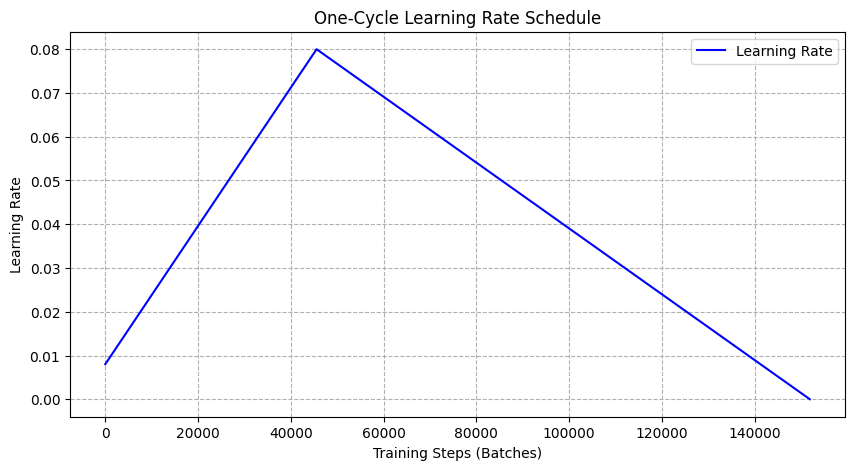

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(one_cycle_callback.history, color='blue', label='Learning Rate')
plt.title('One-Cycle Learning Rate Schedule')
plt.xlabel('Training Steps (Batches)')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

### Training and Validation Performance Curves
Visualize the accuracy and loss for both Phase 1 (One-Cycle) and Phase 2 (Fine-Tuning). The red dotted line indicates the split between the two training strategies.

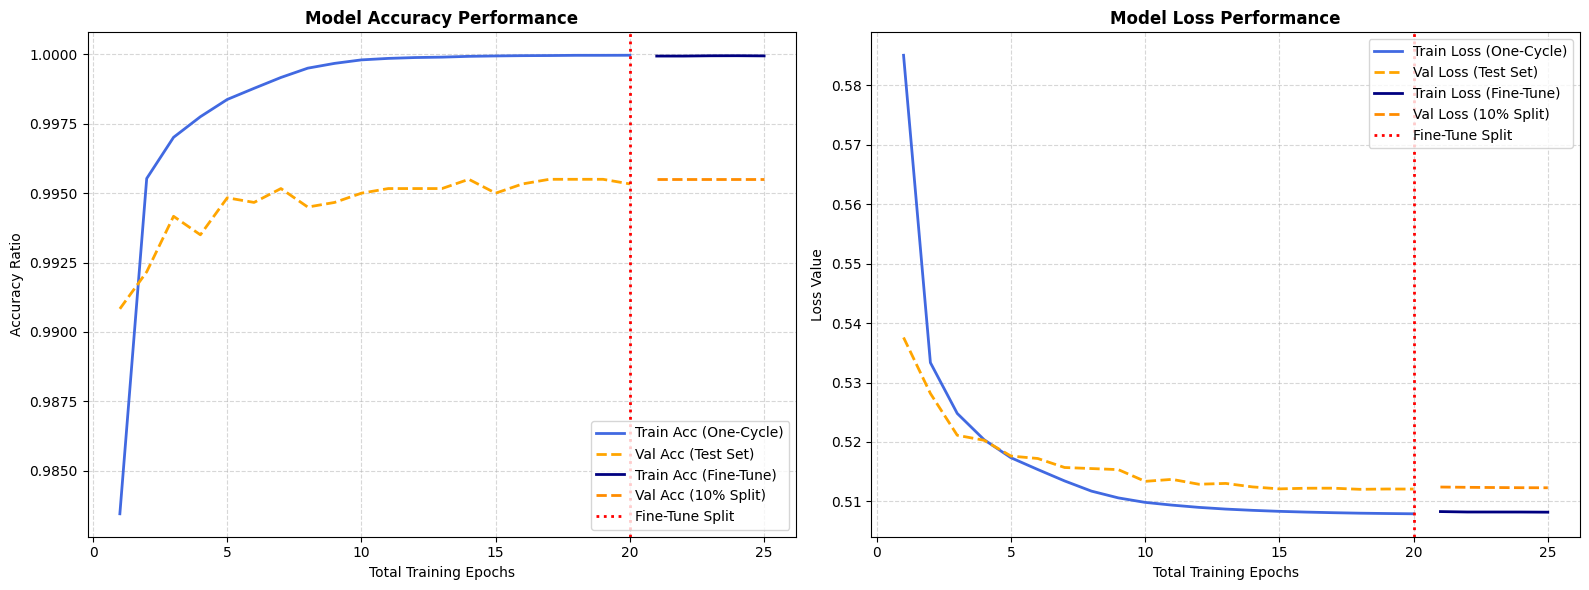

In [30]:
# 1. Extract metric arrays from Phase 1 (One-Cycle)
acc_p1 = history.history['accuracy']
val_acc_p1 = history.history['val_accuracy']
loss_p1 = history.history['loss']
val_loss_p1 = history.history['val_loss']

# 2. Extract metric arrays from Phase 2 (Fine-Tuning)
acc_p2 = fine_tune_history.history['accuracy']
val_acc_p2 = fine_tune_history.history['val_accuracy']
loss_p2 = fine_tune_history.history['loss']
val_loss_p2 = fine_tune_history.history['val_loss']

# 3. Construct sequential epoch coordinate steps
epochs_p1 = np.arange(1, len(acc_p1) + 1)
epochs_p2 = np.arange(len(acc_p1) + 1, len(acc_p1) + len(acc_p2) + 1)
phase_boundary = len(acc_p1)

# Create a clean 1x2 layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ==============================================================================
# PANEL 1: ACCURACY CURVES (One-Cycle + Fine-Tuning)
# ==============================================================================
# One-Cycle Phase
ax1.plot(epochs_p1, acc_p1, label='Train Acc (One-Cycle)', color='royalblue', linewidth=2)
ax1.plot(epochs_p1, val_acc_p1, label='Val Acc (Test Set)', color='orange', linewidth=2, linestyle='--')
# Fine-Tuning Phase
ax1.plot(epochs_p2, acc_p2, label='Train Acc (Fine-Tune)', color='navy', linewidth=2)
ax1.plot(epochs_p2, val_acc_p2, label='Val Acc (10% Split)', color='darkorange', linewidth=2, linestyle='--')

ax1.axvline(x=phase_boundary, color='red', linestyle=':', linewidth=2, label='Fine-Tune Split')
ax1.set_title('Model Accuracy Performance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Training Epochs')
ax1.set_ylabel('Accuracy Ratio')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right')

# ==============================================================================
# PANEL 2: LOSS CURVES (One-Cycle + Fine-Tuning)
# ==============================================================================
# One-Cycle Phase
ax2.plot(epochs_p1, loss_p1, label='Train Loss (One-Cycle)', color='royalblue', linewidth=2)
ax2.plot(epochs_p1, val_loss_p1, label='Val Loss (Test Set)', color='orange', linewidth=2, linestyle='--')
# Fine-Tuning Phase
ax2.plot(epochs_p2, loss_p2, label='Train Loss (Fine-Tune)', color='navy', linewidth=2)
ax2.plot(epochs_p2, val_loss_p2, label='Val Loss (10% Split)', color='darkorange', linewidth=2, linestyle='--')

ax2.axvline(x=phase_boundary, color='red', linestyle=':', linewidth=2, label='Fine-Tune Split')
ax2.set_title('Model Loss Performance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Training Epochs')
ax2.set_ylabel('Loss Value')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Test-Time Augmentation (TTA) Implementation
Define a function to perform Test-Time Augmentation. By averaging predictions from the original image and slightly rotated versions, we can stabilize the model's output on ambiguous edge cases.

In [31]:
def predict_with_tta(model, X_test_raw, max_angle=4):
    """
    Generates predictions by averaging probabilities from the raw images,
    plus deterministically rotated versions (+max_angle and -max_angle)
    to stabilize edge-case classification boundaries.
    """
    print("Computing baseline predictions...")
    prob_raw = model.predict(X_test_raw, verbose=1)

    # Deterministic local helper to ensure exact angle offsets during evaluation
    def _rotate_fixed(image, exact_angle):
        rotated = rotate(image.squeeze(), exact_angle, reshape=False, order=1, mode='nearest')
        return np.clip(rotated, 0.0, 1.0).reshape(image.shape)

    print(f"Computing TTA Version 1 (Exact +{max_angle}° Rotation)...")
    X_rot_pos = np.array([_rotate_fixed(img, max_angle) for img in X_test_raw])
    prob_rot_pos = model.predict(X_rot_pos, verbose=1)

    print(f"Computing TTA Version 2 (Exact -{max_angle}° Rotation)...")
    X_rot_neg = np.array([_rotate_fixed(img, -max_angle) for img in X_test_raw])
    prob_rot_neg = model.predict(X_rot_neg, verbose=1)

    # Direct element-wise blend of probability matrices
    final_prob = (prob_raw + prob_rot_pos + prob_rot_neg) / 3.0
    return final_prob

### Generating Probabilities and Final Predictions
Apply TTA to the test set to generate final class probabilities and determine the predicted class labels by selecting the index with the highest probability.

In [32]:
y_prob = predict_with_tta(model, X_test)
y_pred = y_prob.argmax(axis=-1)

Computing baseline predictions...


2026-06-01 03:01:30.762346: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Computing TTA Version 1 (Exact +4° Rotation)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Computing TTA Version 2 (Exact -4° Rotation)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Primary Classification Metrics
Calculate and display the weighted Accuracy, Precision, Recall, and F1-Score to evaluate the model's overall performance on the test set.

In [33]:
y_true_stable = y_test_one_hot.argmax(axis=-1)
accuracy = accuracy_score(y_true_stable, y_pred) * 100
precision = precision_score(y_true_stable, y_pred, average='weighted', zero_division=0) * 100
recall = recall_score(y_true_stable, y_pred, average='weighted', zero_division=0) * 100
f1 = f1_score(y_true_stable, y_pred, average='weighted', zero_division=0) * 100

print(f'\nFinal Metrics Using Test-Time Augmentation (TTA):')
print(f'Accuracy:             {accuracy:.6f}%')
print(f'Precision (Weighted): {precision:.6f}%')
print(f'Recall (Weighted):    {recall:.6f}%')
print(f'F1-Score (Weighted):  {f1:.6f}%')


Final Metrics Using Test-Time Augmentation (TTA):
Accuracy:             99.710000%
Precision (Weighted): 99.710186%
Recall (Weighted):    99.710000%
F1-Score (Weighted):  99.709989%


### Advanced Performance Evaluation
Calculate advanced metrics including ROC AUC (One-vs-Rest), Log Loss, Cohen's Kappa, and Top-3 Accuracy to provide a comprehensive view of model reliability and confidence.

In [34]:
roc_auc = roc_auc_score(y_true_stable, y_prob, multi_class='ovr') * 100
print(f'ROC AUC Score:        {roc_auc:.6f}%')

loss = log_loss(y_true_stable, y_prob, labels=np.arange(10))
print(f'Log Loss:             {loss:.6f}')

kappa = cohen_kappa_score(y_true_stable, y_pred)
print(f'Cohen Kappa Score:    {kappa:.6f}')

mcc = matthews_corrcoef(y_true_stable, y_pred)
print(f'Matthews Corr Coeff:  {mcc:.6f}')

top_3_accuracy = top_k_accuracy_score(y_true_stable, y_prob, k=3) * 100
print(f'Top-3 Accuracy Score: {top_3_accuracy:.6f}%')

ROC AUC Score:        99.977579%
Log Loss:             0.102104
Cohen Kappa Score:    0.996777
Matthews Corr Coeff:  0.996777
Top-3 Accuracy Score: 99.980000%


### Label Binarization for Advanced Metrics
Prepare the ground truth labels in a format compatible with multi-class ROC AUC and Precision-Recall analysis.

In [35]:
y_test_binarized = y_test_one_hot
n_classes = y_test_binarized.shape[1]

### Confusion Matrix Visualization
Generate and plot a confusion matrix to identify which digits are being confused by the model.

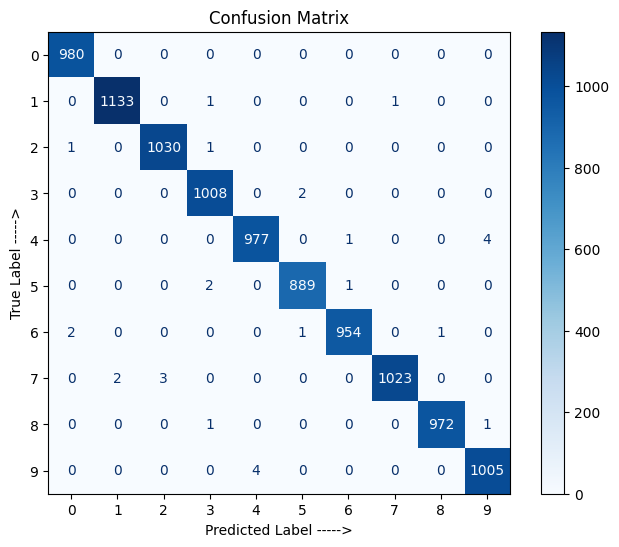

In [36]:
cm = confusion_matrix(y_true_stable, y_pred)

cm_display = ConfusionMatrixDisplay(cm)
fig, ax = plt.subplots(figsize=(8, 6))
cm_display.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label ----->")
ax.set_ylabel("True Label ----->")
plt.show()

### Per-Class Accuracy Analysis
Visualize the accuracy for each individual digit to identify specific weaknesses.

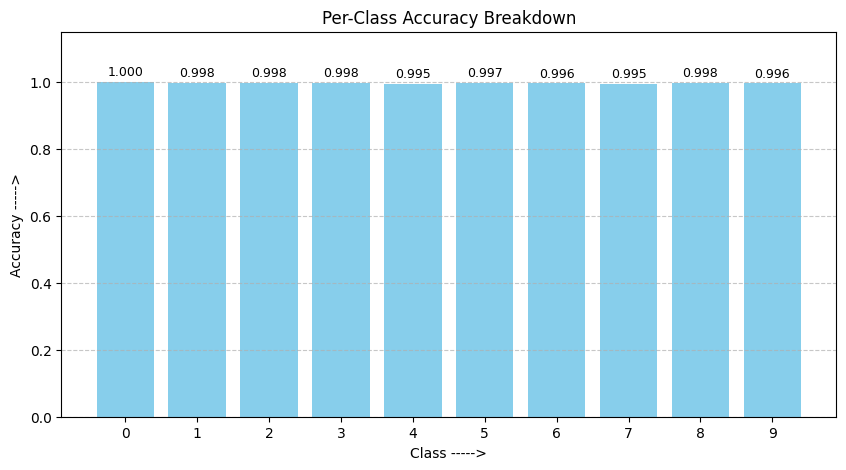

In [37]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
bars = plt.bar(
    range(len(per_class_accuracy)),
    per_class_accuracy,
    tick_label=range(len(per_class_accuracy)),
    color="skyblue",
)

# Add exact value labels above the bars safely
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xlabel("Class ----->")
plt.ylabel("Accuracy ----->")
plt.title("Per-Class Accuracy Breakdown")
plt.ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### Precision-Recall and ROC Curves
Plot multiclass Precision-Recall and ROC curves to evaluate the trade-off between sensitivity and specificity.

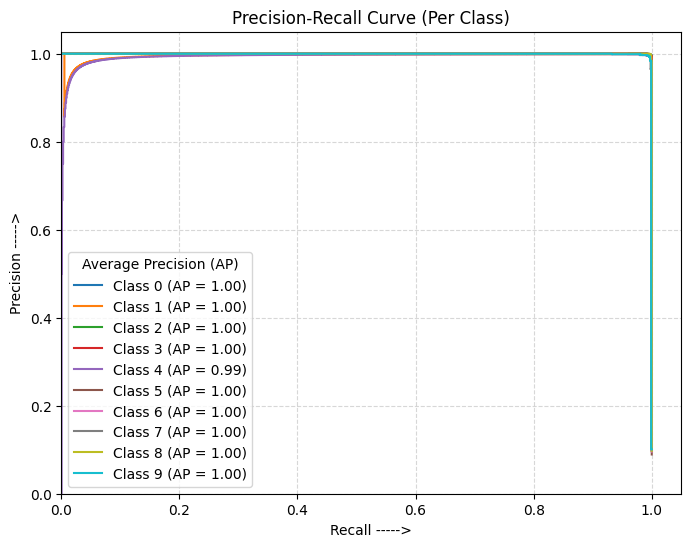

In [38]:
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_prob[:, i])
    average_precision = average_precision_score(y_test_binarized[:, i], y_prob[:, i])
    plt.plot(
        recall,
        precision,
        drawstyle="steps-post",
        label=f"Class {i} (AP = {average_precision:.2f})",
    )

plt.xlabel("Recall ----->")
plt.ylabel("Precision ----->")
plt.title("Precision-Recall Curve (Per Class)")
plt.legend(loc="lower left", title="Average Precision (AP)")
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Receiver Operating Characteristic (ROC) Curve
Plot the ROC curve for each class to visualize the performance of the multiclass classifier. This shows the trade-off between the True Positive Rate and False Positive Rate, with the Area Under the Curve (AUC) representing the degree of separability.

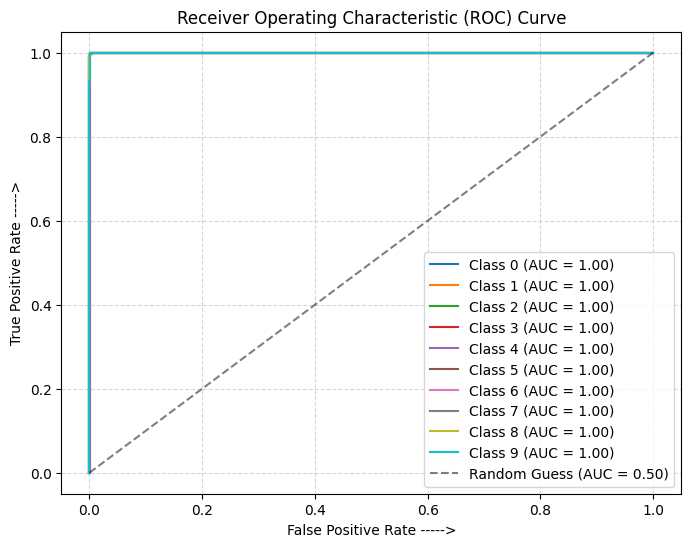

In [39]:
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5,label="Random Guess (AUC = 0.50)") 
plt.legend(loc="lower right")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate ----->")
plt.ylabel("True Positive Rate ----->")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Prediction Confidence Histogram
Examine the distribution of the model's highest predicted probabilities to assess its confidence levels.

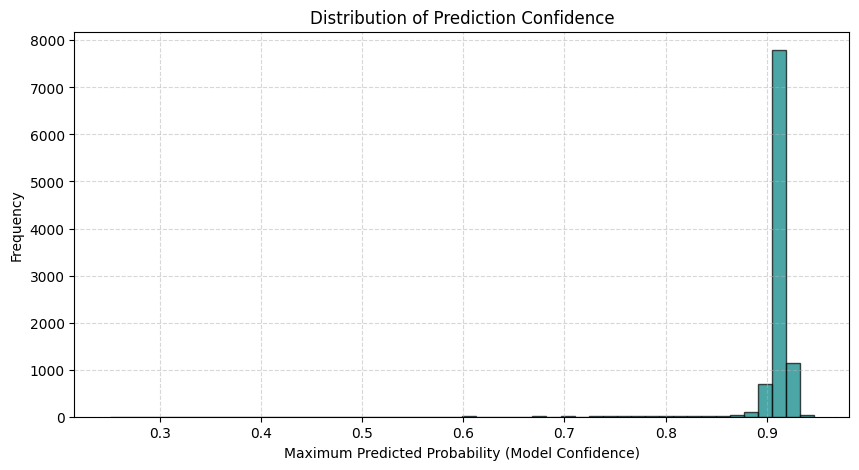

In [40]:
y_pred_proba_max = np.max(y_prob, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(y_pred_proba_max, bins=50, edgecolor="black", color="teal", alpha=0.7)
plt.xlabel("Maximum Predicted Probability (Model Confidence)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Confidence")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Classification Report Heatmap
Visualize the classification report (precision, recall, f1-score) as a heatmap for easy interpretation.

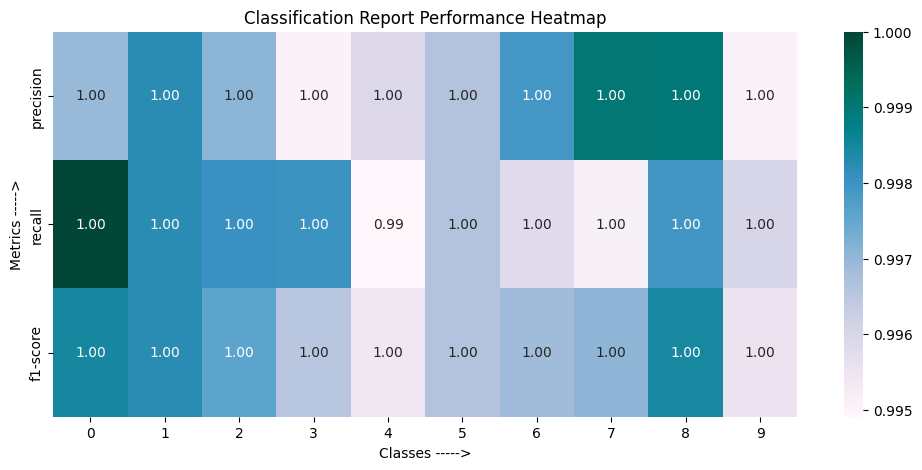

In [41]:
clf_report = classification_report(y_true_stable, y_pred, output_dict=True)
clf_report_df = pd.DataFrame(clf_report).transpose().drop(columns=["support"])

plt.figure(figsize=(12, 5))
# iloc[:-3, :] drops overall summary averages ('accuracy', 'macro avg', 'weighted avg')
sns.heatmap(clf_report_df.iloc[:-3, :].T, annot=True, cmap="PuBuGn", fmt=".2f")
plt.title("Classification Report Performance Heatmap")
plt.ylabel("Metrics ----->")
plt.xlabel("Classes ----->")
plt.show()

### Error Analysis
Identify and isolate indices where the predicted label does not match the true label.

In [42]:
misclassified_idx = np.where(y_true_stable != y_pred)[0]
total_errors = len(misclassified_idx)
print(f"\nTotal Misclassified Images: {total_errors}")


Total Misclassified Images: 29


### Visualization of Misclassified Images
Display the first 25 images that the model failed to classify correctly, showing both true and predicted labels.

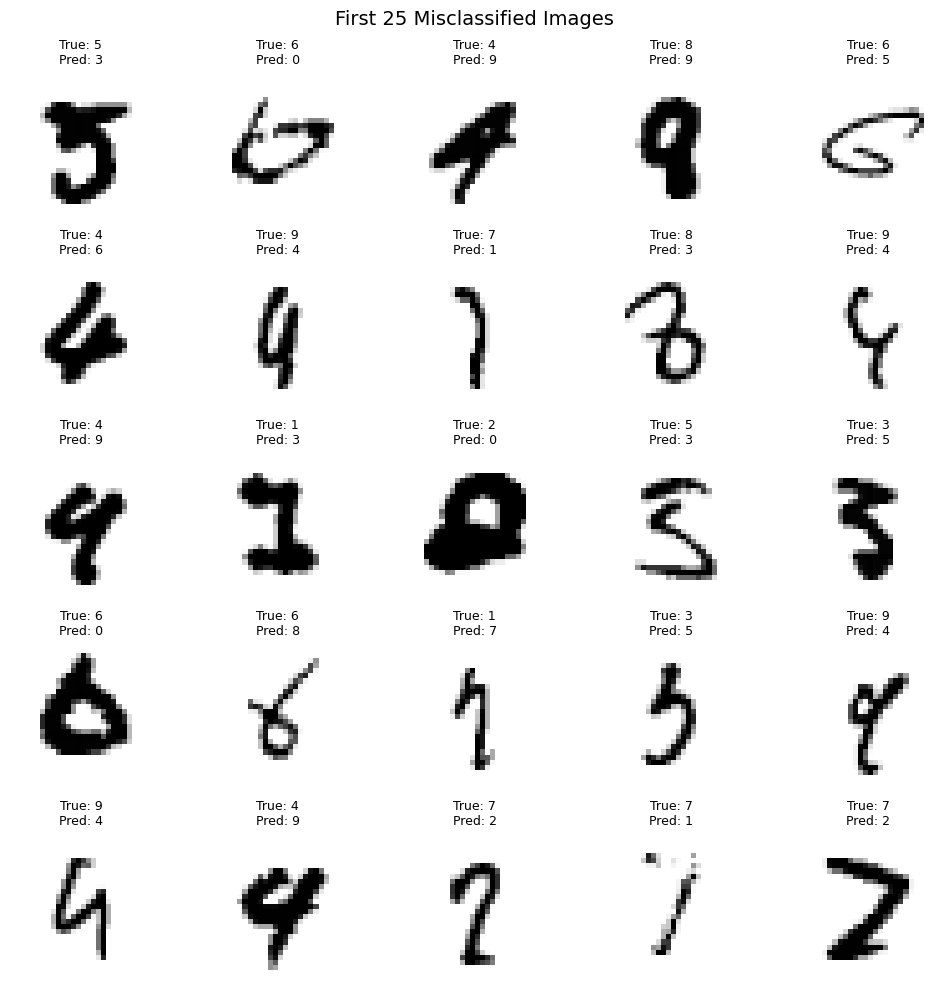

In [43]:
num_to_show = min(25, total_errors)
ncols = min(5, num_to_show)
nrows = int(np.ceil(num_to_show / ncols))

plt.figure(figsize=(2.0 * ncols, 2.0 * nrows))
plt.suptitle(f"First {num_to_show} Misclassified Images", fontsize=14, y=0.98)

for i in range(num_to_show):
    idx = misclassified_idx[i]
    plt.subplot(nrows, ncols, i + 1)
    image_data = X_test[idx].reshape(28, 28)
    plt.imshow(image_data, cmap="binary")
    plt.title(f"True: {y_true_stable[idx]}\nPred: {y_pred[idx]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Model Serialization
Save the trained model to a file for future deployment or inference.

In [44]:
model.save("CNN_model_mnist.keras")
print("\nCNN model native Keras asset file saved successfully.")


CNN model native Keras asset file saved successfully.
